# Aircraft Engine Predictive Maintenance Project : Remaining Useful Life (RUL) Prediction
## Project Overview:
---
## 1. Dataset Understanding:
#### The dataset used for this project can be sourced [here](https://www.kaggle.com/datasets/fareselgohary003/nasa-cmapss-turbofan-engine-rul-dataset) from Kaggle

The dataset is split into three distinct files:
1. **`train_FD001.txt`:** Contains complete continuous lifecycles for 100 individual engines. Each engine begins operating in a healthy state and develops a fault that degrades over time until it reaches a physical point of failure.

2. **`test_FD001.txt`:** Contains ongoing operational logs for 100 separate engines. Crucially, these time series are deliberately truncated by NASA at a random point mid-operation. The fleet is still running, and the true point of failure is hidden.

3. **`RUL_FD001.txt`:** The official data science "answer key" containing the exact number of remaining flight cycles left for each corresponding engine in the test set.


## Variables :
Each raw text log contains 26 unlabelled, space-separated columns mapping out the technical operational envelope of the turbofan:
##### * Temperature Sensors
- Sensor 1: Total temperature at fan inlet (°R)

- Sensor 2: Total temperature at LPC (Low Pressure Compressor) outlet (°R)

- Sensor 3: Total temperature at HPC (High Pressure Compressor) outlet (°R)

- Sensor 4: Total temperature at LPT (Low Pressure Turbine) inlet (°R)

- Sensor 7: Total temperature at MIT (High Pressure Turbine) outlet (°R)

- Sensor 11: Turbine exhaust gas temperature (°R)

- Sensor 15: Bypass duct total temperature (°R)
#### Temperature readings in this simulation are recorded in Degrees Rankine, a standard thermodynamic absolute temperature scale used in US aerospace engineering).

##### * Pressure Sensors
- Sensor 5: Total pressure at fan inlet (psia)

- Sensor 8: Total pressure at bypass duct (psia)

- Sensor 12: Total pressure at HPC outlet (psia)

- Sensor 13: Total pressure at LPT outlet (psia)

- Sensor 16: Engine pressure ratio (P50/P2)

- Sensor 17: Static pressure at HPC outlet (Ps3) (psia)

##### * Rotational Speeds & Component Flow Rates
- Sensor 9: Physical fan speed (NRf) (rpm)

- Sensor 10: Physical core speed (NRc) (rpm)

- Sensor 14: Corrected fan speed (NfRstd) (rpm)

- Sensor 20: Corrected core speed (NcRstd) (rpm)

- Sensor 6: Fuel flow (Wf) (pps - pounds per second)

- Sensor 18: Bleed enthalpy (h)

- Sensor 19: Demanded fan speed (Rfan) (rpm)

- Sensor 21: Demanded corrected fan speed (Rcore) (rpm)
---

## 2. Business Understanding & Project Objectives
* ### The problem at hand:
For most aviation Operators, equipment downtime is exceptionally costly, and component failure can be catastrophic. 
Traditional maintenance strategies generally fall into two inefficient categories:
1. **Reactive Maintenance (Run-to-Failure):** Components are used until they break. While this maximizes the lifespan of the part, it introduces extreme safety risks, leads to unscheduled operational disruptions, and incurs massive emergency repair costs.
2. **Preventative Maintenance (Scheduled):** Components are replaced at strict, conservative time intervals regardless of their actual wear. While safer, this wastes massive amounts of money by discarding perfectly healthy parts prematurely.

* ### The Predictive Maintenance Solution:
This project addresses these inefficiencies by shifting to a **Predictive Maintenance** framework. By utilizing multi-sensor machine learning to predict the exact **Remaining Useful Life (RUL)** of an active engine, aviation operators can:
* **Optimize Fleet Safety:** Ground aircraft and schedule overhauls *just before* components enter high-risk degradation thresholds.
* **Minimize Maintenance Costs:** Maximize the operational lifespan of expensive turbofan parts, avoiding premature replacements.
* **Streamline Logistics:** Ensure replacement parts and engineering crews are pre-staged at the hangar, drastically reducing aircraft turnaround times.
---
 ## 3. Primary Objective: 
 #### Build and fine-tune a high-precision regression architecture capable of mapping real-time sensor streams to an accurate RUL countdown, minimizing prediction error (MAE/RMSE) on completely unseen operational assets.
#### Technological stack to be used : 
* #### Numpy and Pandas for numerical operations
* #### Seaborn and matplotlib for visualisations 
* #### Random Forest regressor and XG Boost as models for prediction
---




## 1. IMPORTING LIBRARIES AND LOADING DATASET

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sbs

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [3]:
## defining column names, (also variables to be used) manually:
index_names = ['engine_id', 'cycle']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1,22)] # Generates sensor_1 to sensor_21
col_names = index_names + setting_names + sensor_names
all_sensors = [f'sensor_{i}' for i in range(1, 22)]

## Converting the .txt train train_df
# to .csv:
train_df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names = col_names)
train_df.to_csv('train_FD001.csv', index=False)
train_df.head()

<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_21400\3404608753.py:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  train_df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names = col_names)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. FEATURE ENGINEERING (R.U.L)

* ### Creating the target column that is, the number of cycles an engine has left before failure 

In [4]:
## Engineering the Remaining Useful Life(R.U.L)column  --> target variable 
                                  
# 1. Finding the maximum cycle (the breakdown flight) for each unique engine
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']

# 2 ..Merging the maximum cycle back into our main dataframe
train_df = pd.merge(train_df, max_cycle, on='engine_id')

# 3 .Calculating Remaining Useful Life (RUL)
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

## 4 dropping the max cycle column, no longer needed.
train_df_new = train_df.drop(columns=['max_cycle'])

In [5]:
train_df_new.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [7]:
train_df_new.to_csv('new_train_df.csv', index=False)

## 3. EXPLORATORY DATA ANALYSIS AND VISUALISATION

c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\user\anaconda3\envs\data-env\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


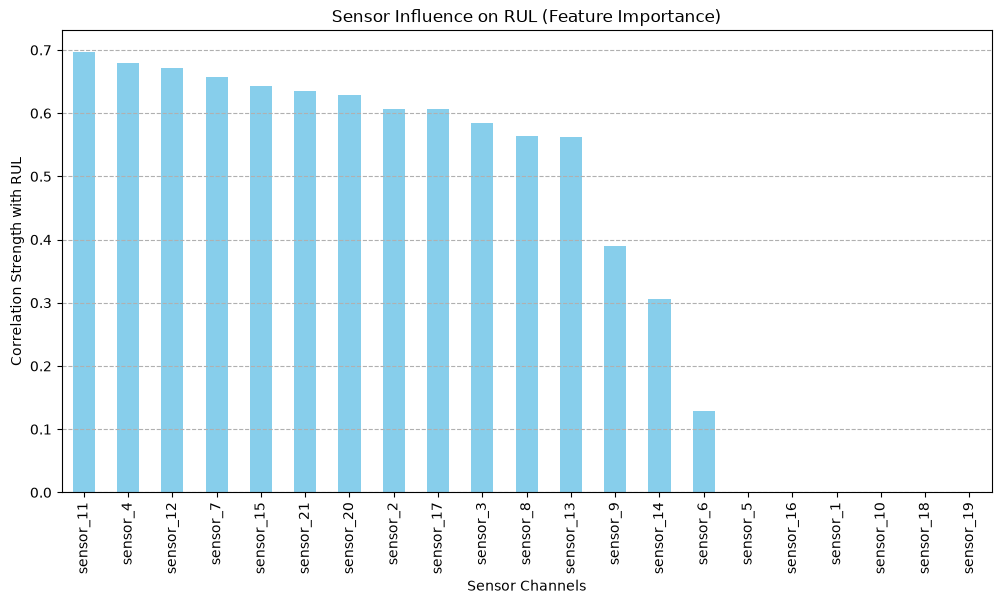

In [ ]:

correlations = train_df[all_sensors].corrwith(train_df['RUL']).abs().sort_values(ascending=False)

### Plotting the influence of each sensor on RUL
plt.figure(figsize=(12, 6))
correlations.plot(kind='bar', color='skyblue')
plt.title('Sensor Influence on RUL (Feature Importance)')
plt.ylabel('Correlation Strength with RUL')
plt.xlabel('Sensor Channels')
plt.grid(axis='y', linestyle='--')
plt.show()

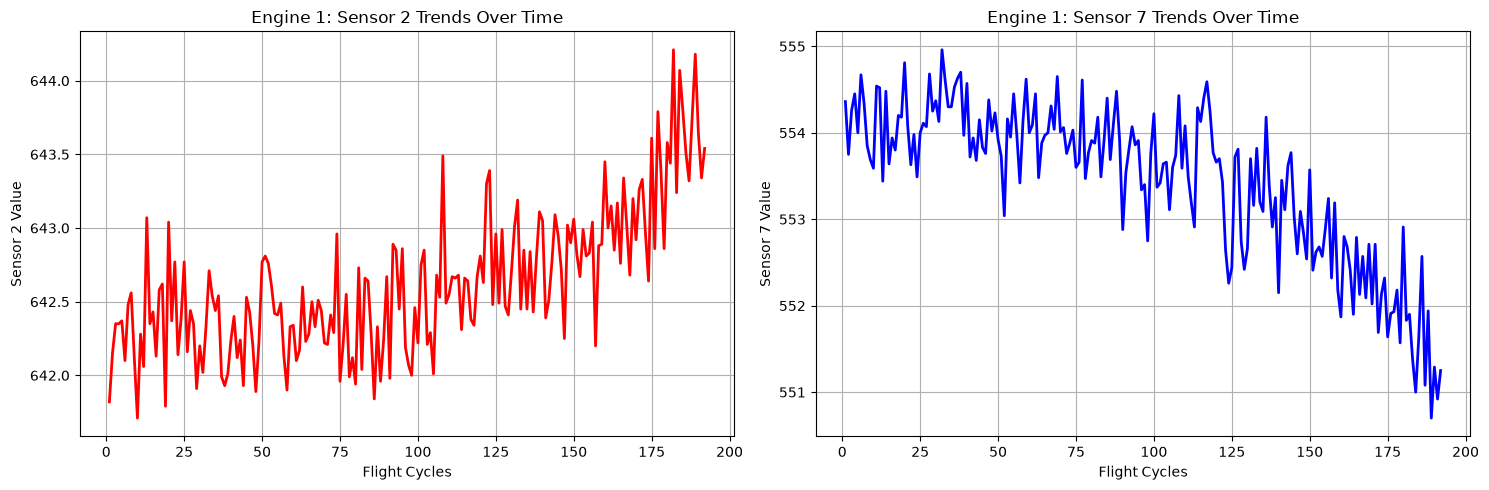

In [24]:
engine_1 = train_df[train_df['engine_id'] == 1] # looking at engine 1 only.

fig, axes = plt.subplots(1, 2, figsize=(15, 5)) ## creating two subplots side by side

# 1 : A graph to show an example of a diagnostic (taken by sensor 2) that rises as engine failure nears
sbs.lineplot(ax=axes[0], data=engine_1, x='cycle', y='sensor_2', color='red', linewidth=2)
axes[0].set_title('Engine 1: Sensor 2 Trends Over Time', fontsize=12)
axes[0].set_xlabel('Flight Cycles', fontsize=10)
axes[0].set_ylabel('Sensor 2 Value', fontsize=10)
axes[0].grid(True)

# 2 : An example of a diagnostic that falls as engine failure nears

sbs.lineplot(ax=axes[1], data=engine_1, x='cycle', y='sensor_7', color='blue', linewidth=2)
axes[1].set_title('Engine 1: Sensor 7 Trends Over Time', fontsize=12)
axes[1].set_xlabel('Flight Cycles', fontsize=10)
axes[1].set_ylabel('Sensor 7 Value', fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

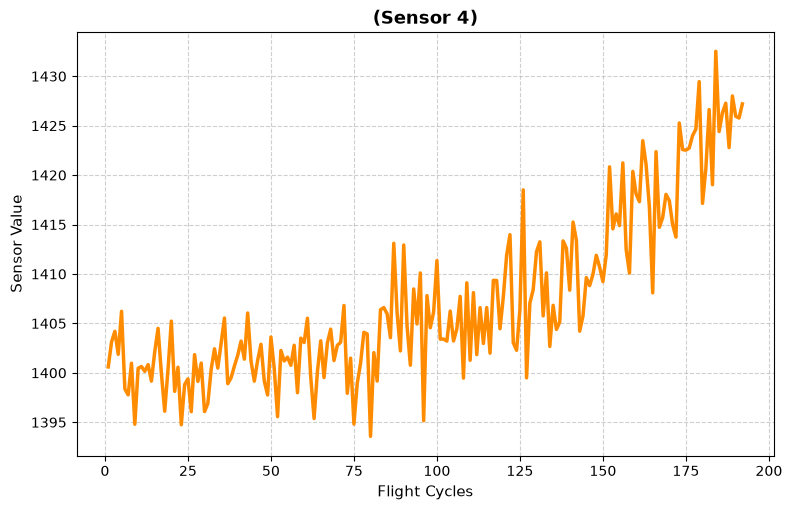

In [25]:
# A graph showing behavior of diagnostic recorded by sensor 4
plt.figure(figsize=(9,5.5))
sbs.lineplot(data=engine_1, x='cycle', y='sensor_4', color='darkorange', linewidth=2.5)
plt.title('(Sensor 4)', fontsize=13, fontweight='bold')
plt.xlabel('Flight Cycles', fontsize=11)
plt.ylabel('Sensor Value', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

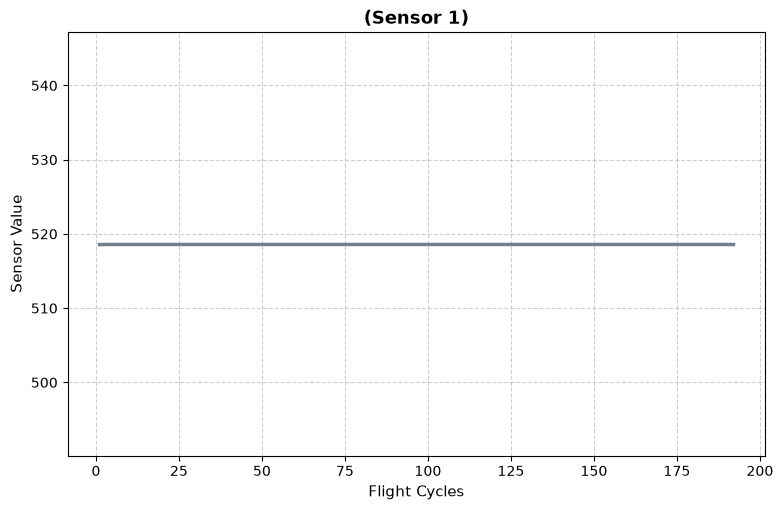

In [26]:
### Sensor 1 :
plt.figure(figsize=(9,5.5))
sbs.lineplot(data=engine_1, x='cycle', y='sensor_1', color='slategray', linewidth=2.5)
plt.title('(Sensor 1)', fontsize=13, fontweight='bold')
plt.xlabel('Flight Cycles', fontsize=11)
plt.ylabel('Sensor Value', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Observations:
---
### As seen from the plots above different sensor values change in magnitude differently, as degradation nears :
* #### Some diagnostic values from certain sensors increase -----|----(These are potentially informative predictors)
* #### Some diagnostic values from certain sensors reduce   -----|
* #### Some remain compeletely flat. (This brings the need to ignore them as they are relevant)

---
## 4. DATA PREPROCESSING (Feature Selection and Normalisation)
---

In [27]:

# 1. Separating features and targets 
X = train_df[all_sensors]
y = train_df['RUL']

# 2. Splitting into Training and validating data
# This keeps the future data completely isolated
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Selection: Calculate 'features_to_drop' ONLY on X_train
features_to_drop = [s for s in all_sensors if X_train[s].std() == 0]
active_features = [s for s in all_sensors if s not in features_to_drop]

# Filter the datasets
X_train = X_train[active_features]
X_val = X_val[active_features]

# 4. Scaling: Fit ONLY on X_train
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Apply the SAME scaling parameters to X_val
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrames
X_train = pd.DataFrame(X_train_scaled, columns=active_features)
X_val = pd.DataFrame(X_val_scaled, columns=active_features)

X_train.head()



,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_20,sensor_21
0,0.381098,0.450900,0.404625,0.0,1.0,0.492754,0.384615,0.143408,0.0,0.341317,0.605544,0.338235,0.171225,0.409773,0.0,0.500000,0.565891,0.611907
1,0.301829,0.517658,0.382343,0.0,1.0,0.716586,0.153846,0.255766,0.0,0.335329,0.867804,0.220588,0.283517,0.215083,0.0,0.166667,0.542636,0.607273
2,0.353659,0.189337,0.336259,0.0,1.0,0.557166,0.169231,0.116845,0.0,0.185629,0.665245,0.338235,0.198627,0.310119,0.0,0.416667,0.658915,0.529627
3,0.463415,0.263841,0.383187,0.0,1.0,0.714976,0.184615,0.160459,0.0,0.281437,0.748401,0.176471,0.226442,0.370912,0.0,0.333333,0.604651,0.764252
4,0.439024,0.369788,0.387407,0.0,1.0,0.507246,0.400000,0.112896,0.0,0.407186,0.594883,0.411765,0.154557,0.379377,0.0,0.416667,0.488372,0.524993


## 5. MODEL TRAINING AND EVALUATION.

In [28]:
## Initialising models:

baseline_model = LinearRegression() # this is my bench mark.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=150, learning_rate=0.03, random_state=42, max_depth= 5,n_jobs = -1)

 ## Training models:
baseline_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

xgb_model.fit(X_train, y_train)




,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [29]:
### Evaluating models on validation data
models = {
    "Linear Regression": baseline_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}


for name, model in models.items():
    # Make predictions on the validation sensors
    predictions = model.predict(X_val)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))
    
    print(f"...... {name} Performance ......")
    print(f"Mean Absolute Error (MAE): {mae:.2f} cycles")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cycles")
    print("-" * 40)

...... Linear Regression Performance ......
Mean Absolute Error (MAE): 34.04 cycles
Root Mean Squared Error (RMSE): 44.32 cycles
----------------------------------------
...... Random Forest Performance ......
Mean Absolute Error (MAE): 29.51 cycles
Root Mean Squared Error (RMSE): 41.34 cycles
----------------------------------------
...... XGBoost Performance ......
Mean Absolute Error (MAE): 29.49 cycles
Root Mean Squared Error (RMSE): 41.08 cycles
----------------------------------------


# Observations:
---

* ### It is noticeable that the XG_Boost model had the least mean squared error, meaning it has the least errors in terms of predicting how many cycles an engine has left before failure

## 6. TESTING MODELS ON UNSEEN DATA (Unbiased Testing)

In [30]:
# Loading the test data.
test_df = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)
true_rul = pd.read_csv('RUL_FD001.txt', sep='\s+', header=None, names=['true_RUL'])

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\user\AppData\Local\Temp\ipykernel_10000\683654439.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  test_df = pd.read_csv('test_FD001.txt', sep='\s+', header=None, names=col_names)
C:\Users\user\AppData\Local\Temp\ipykernel_10000\683654439.py:3: SyntaxWarning: "\s" is an in

In [31]:
# 2. PREPROCESSING THE TEST DATA 

# We only care about the LATEST flight recorded for each engine in the test set
# because that represents the current state of the active aircraft engine.
test_latest_flights = test_df.groupby('engine_id').last().reset_index()

# Extracting only the active, healthy sensor columns I kept during Step 4
X_test_raw = test_latest_flights[active_features]

# Use the EXACT SAME scaler we fitted on our training data 
X_test_scaled = scaler.transform(X_test_raw)
X_test_final = pd.DataFrame(X_test_scaled, columns=active_features)

# Extract our ground truth target column (NASA's answers)
y_test = true_rul['true_RUL']


# 3. EVALUATING THE TRAINED MODELS ON TRUE UNSEEN DATA
print("=== Final Scores on Unseen NASA Test Set ===")

for name, model in models.items():
    # Predict the remaining flights for the active test engines
    test_predictions = model.predict(X_test_final)
    
    # Calculate final performance metrics against NASA's answer key
    test_mae = mean_absolute_error(y_test, test_predictions)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    
    print(f"[{name}]")
    print(f"  Final MAE : {test_mae:.2f} cycles")
    print(f"  Final RMSE: {test_rmse:.2f} cycles")
    print("-" * 35)

=== Final Scores on Unseen NASA Test Set ===
[Linear Regression]
  Final MAE : 25.65 cycles
  Final RMSE: 32.17 cycles
-----------------------------------
[Random Forest]
  Final MAE : 24.23 cycles
  Final RMSE: 33.11 cycles
-----------------------------------
[XGBoost]
  Final MAE : 23.45 cycles
  Final RMSE: 31.91 cycles
-----------------------------------


# EXPORTATION AND DEPLOYMENT.

In [32]:
# --- Exporting for Streamlit Deployment ---
# Save the model and the scaler so the App can "re-load" them
joblib.dump(xgb_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save the list of features so the app knows the exact input order
joblib.dump(active_features, 'features.pkl')


['features.pkl']

---
# Conclusion
---
* ### This project developed and evaluated machine learning models for predicting the Remaining Useful Life (RUL) of aircraft engines using the NASA CMAPSS dataset. The objective was to determine how many operating cycles an engine has left before failure, enabling maintenance teams to make informed decisions before critical breakdowns occur.

* ### The analysis showed that sensor data contains meaningful patterns related to engine degradation, allowing machine learning models to estimate RUL with reasonable accuracy. Multiple models were trained and compared, ranging from simple linear models to more advanced ensemble methods, demonstrating that machine learning can effectively support predictive maintenance strategies.

* ### By predicting engine health in advance, airlines and maintenance organizations can move away from reactive maintenance practices and adopt data-driven maintenance schedules. This can lead to reduced downtime, improved operational efficiency, enhanced safety, and lower maintenance costs.

### **Overall, the project demonstrates that predictive maintenance powered by machine learning has significant potential to improve reliability and decision-making in the aviation industry.**



---
# Recommendations
---
Based on the findings of this study, the following recommendations are proposed:

* #### Trigger Dynamic Inspection Windows: Replace fixed, 150-cycle overhaul rules with dynamic inspections triggered the moment the model flags an asset's RUL dropping below 30 cycles.

* ####  Flag High-Pressure Turbine Degradation: Monitor Sensor 4 (Inlet Temperature) and Sensor 7 (Outlet Temperature) as primary structural health indicators. When these profiles drop below baseline thermal efficiency, fast-track the engine for immediate teardown.

* ####  Streamline Parts Inventory: Use the model’s RUL lead time to automate supply-chain logistics—pre-ordering replacement parts and scheduling hangar labor before terminal wear occurs to minimize inventory storage costs.

* ####  To facilitate adoption by maintenance personnel, the trained model should be deployed as a lightweight Streamlit application. Instead of interacting with Python code, engineers can upload an engine's latest sensor readings or enter them manually to receive an instant Remaining Useful Life (RUL) prediction.
